# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.


1. I chose the Census Income dataset.

2. My label is income. I will build a classification model that predicts whether a person's annual income is greater than $50K or less than or equal to $50K based on their demographic and employment info.

3. I plan to use features such as age, workclass, education, education-num, marital-status, occupation, relationship, race, sex, hours-per-week, capital-gain, capital-loss, and native-country. These features are likely to have an impact on a person's income level.

4. Predicting income is useful because it helps organizations better understand demographics of people and make data-driven decisions. For example, financial institutions can use this model to estimate credit risk or determine loan eligibility, while businesses can use it for customer segmentation and targeted marketing. Government agencies and researchers can also use income predictions to analyze economic trends and identify communities that may benefit from assistance programs.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [3]:
1. Data preparation techniques

I will first check the dataset for missing values and handle them if necessary. Since the dataset contains several categorical features, I will use one-hot encoding to convert them into numerical values. I will remove any irrelevant features that do not help predict income and examine the data for outliers. Because logistic regression is sensitive to feature scales, I will also standardize the numerical features. Finally, I will check whether the income classes are imbalanced and address if needed.

2. Machine learning model

I will use Logistic Regression because the goal is to predict whether a person's income is greater than $50K or less than or equal to $50K, making this a binary classification problem. Logistic Regression is well-suited for this type of prediction, is efficient to train, and provides probabilities for each class. To improve model performance, I will scale the numerical features before training.

3. Model evaluation

I will evaluate the model using accuracy, precision, recall, F1-score, and a confusion matrix. Accuracy measures overall performance, while precision and recall provide more insight into how well the model predicts each income class. The F1-score balances precision and recall, and the confusion matrix helps identify the types of classification errors the model makes. If necessary, I will tune the model's parameters and improve feature selection to achieve better performance.

SyntaxError: invalid syntax (<ipython-input-3-9c294ab0be96>, line 1)

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64


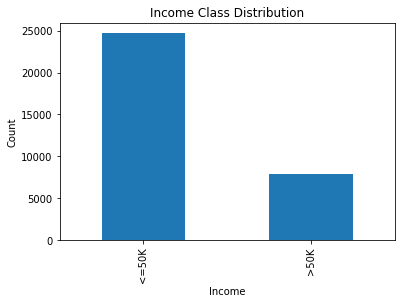

In [4]:
import matplotlib.pyplot as plt

#count each income class
print(df["income_binary"].value_counts())

df["income_binary"].value_counts().plot(kind="bar")

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32399.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.589216  1.897784e+05      10.080679    615.907773     87.303830   
std       13.647862  1.055500e+05       2.572720   2420.191974    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  14084.000000   4356.000000   

       hours-per-week  
count    32236.000000  
mean        40.450428  
std         12.353748  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

Data Types:
age               float64
workclass          objec

<Figure size 576x360 with 0 Axes>

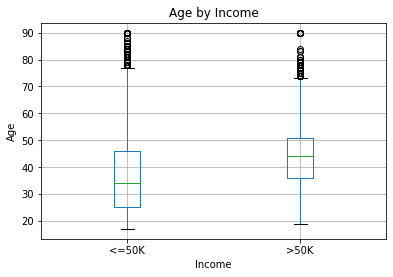

In [5]:
import matplotlib.pyplot as plt

# Summary statistics
print(df.describe())

# data types
print("\nData Types:")
print(df.dtypes)

# missing values
print("\nMissing Values:")
print(df.isnull().sum())

# distribution of the label
print("\nIncome Distribution:")
print(df["income_binary"].value_counts())

# relationship between age & income
plt.figure(figsize=(8,5))
df.boxplot(column="age", by="income_binary")

plt.title("Age by Income")
plt.suptitle("")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The dataset contains both numerical and categorical features. I found that the categorical features will need to be converted using one-hot encoding before training the model. The numerical features will be standardized because Logistic Regression performs better when features are on a similar scale.

I also examined the class distribution and found that the dataset is somewhat imbalanced, with more individuals earning less than or equal to $50K than those earning above $50K. If this imbalance affects the model's performance, I will consider using class weights during training. Overall, the exploratory analysis helped identify the preprocessing steps needed before building the model.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. This dataset contains features such as race, sex, age, and education, which are sensitive characteristics that could introduce bias into the model. Historical income data may reflect existing social and economic inequalities, causing the model to learn patterns that unfairly disadvantage certain groups. Features like occupation, education, and marital status may also indirectly represent protected characteristics. 

2. Wrong predictions could negatively affect individuals if the model were used to support decisions involving loans, hiring, insurance, or financial assistance. People who are incorrectly predicted to have a lower income could lose opportunities or receive unfair treatment. To reduce these risks, the model should be evaluated for fairness across different demographic groups and should be used only as a decision-support tool rather than the sole basis for important decisions.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# sep features & label

X = df.drop("income_binary", axis=1)
y = df["income_binary"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

#scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (26048, 97)
Testing set shape: (6513, 97)


# Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I prepared the data by separating the features from the target variable income_binary. The categorical features were converted into numerical values using one-hot encoding so they could be used by the Logistic Regression model. I used drop_first=True to avoid creating redundant dummy variables.

Next, I split the dataset into training and testing sets using an 80/20 split. I used stratified sampling to preserve the original distribution of the income classes in both sets, ensuring the model would be trained and evaluated on representative data.

Finally, I standardized the feature values using StandardScaler. Logistic Regression performs better when numerical features are on a similar scale, so standardizing the data helps the model converge more efficiently and prevents features with larger values from having a disproportional influence on the model.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [12]:
# Create labeled examples from the dataset
X = df.drop("income_binary", axis=1)
y = df["income_binary"]

for col in ["age", "hours-per-week"]:
    X[col] = X[col].fillna(X[col].median())

for col in ["workclass", "occupation", "native-country"]:
    X[col] = X[col].fillna(X[col].mode()[0])

X = pd.get_dummies(X, drop_first=True)

feature_names = X.columns

In [13]:
# Create training and test sets out of the labeled examples 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (26048, 97)
Testing set shape: (6513, 97)


NaNs in X_train: 385
NaNs in y_train_bin: 0
Unique values in y_train_bin: [1 0]


In [14]:
# Train, test and evaluate your model
# YOUR CODE HERE

y_train_bin = y_train.apply(lambda x: 1 if x.strip() == ">50K" else 0)
y_test_bin = y_test.apply(lambda x: 1 if x.strip() == ">50K" else 0)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train_bin)

y_pred = lr_model.predict(X_test)

acc_baseline = accuracy_score(y_test_bin, y_pred)
f1_baseline = f1_score(y_test_bin, y_pred, average='binary')

print("Baseline Logistic Regression")
print("Accuracy:", acc_baseline)
print("F1 Score:", f1_baseline)

Baseline Logistic Regression
Accuracy: 0.8549055734684478
F1 Score: 0.6715328467153284


In [15]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring='f1',
    cv=5
)

grid_search.fit(X_train, y_train_bin)

print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Best hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation F1 score: 0.6535261275426965


In [16]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
# YOUR CODE HERE

best_lr_model = grid_search.best_estimator_

y_pred_final = best_lr_model.predict(X_test)

acc_final = accuracy_score(y_test_bin, y_pred_final)
f1_final = f1_score(y_test_bin, y_pred_final, average='binary')

print("Final Logistic Regression (tuned)")
print("Accuracy:", acc_final)
print("F1 Score:", f1_final)

Final Logistic Regression (tuned)
Accuracy: 0.8544449562413634
F1 Score: 0.6699164345403898


Top 10 features increasing predicted probability of >50K income:
                              Feature  Coefficient
29  marital-status_Married-civ-spouse     0.909566
3                        capital-gain     0.840055
2                       education-num     0.562758
5                      hours-per-week     0.386981
56              sex_selfID_Non-Female     0.384457
0                                 age     0.304411
51                  relationship_Wife     0.278962
4                        capital-loss     0.252962
36         occupation_Exec-managerial     0.252329
55                         race_White     0.208250

Top 10 features decreasing predicted probability of >50K income:
                         Feature  Coefficient
37    occupation_Farming-fishing    -0.172300
6            workclass_Local-gov    -0.173550
41    occupation_Priv-house-serv    -0.187938
81         native-country_Mexico    -0.194182
94  native-country_United-States    -0.194603
31  marital-status_Never-married

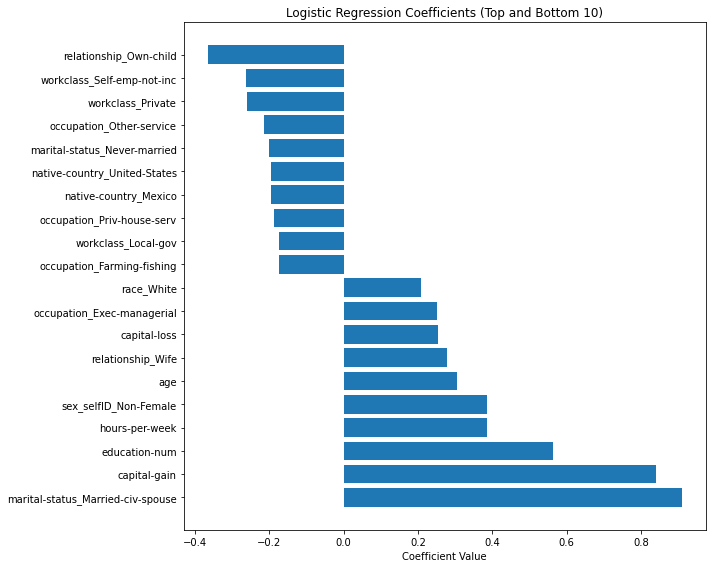

In [17]:
# Interpret your model's outputs 
# YOUR CODE HERE

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_lr_model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print("Top 10 features increasing predicted probability of >50K income:")
print(coefficients.head(10))

print("\nTop 10 features decreasing predicted probability of >50K income:")
print(coefficients.tail(10))

plt.figure(figsize=(10,8))
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Logistic Regression Coefficients (Top and Bottom 10)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose Logistic Regression since this is a binary classification problem (>50K vs <=50K). It's efficient to train and produces interpretable coefficients, which matters here since understanding why the model predicts high income is as useful as the prediction itself.

2. GridSearchCV found C=0.1 as the best hyperparameter (F1 = 0.6535 in cross-validation). The final tuned model's test F1 (0.6699) was nearly identical to the baseline's (0.6715), suggesting the default settings were already close to optimal and performance isn't very sensitive to tuning here.

3. Since features were standardized, coefficients are comparable. Strongest positive predictors of >50K income were marital-status_Married-civ-spouse, capital-gain, and education-num. Strongest negative predictors were relationship_Own-child, workclass_Self-emp-not-inc, and workclass_Private. The final model reached 85.4% accuracy and 0.67 F1; the gap reflects class imbalance (about 76% of individuals earn <=50K), so the model favors the majority class.

4. The model uses race and sex_selfID directly, with race_White positively linked to >50K predictions. This is risky if used for lending or hiring, since it could reinforce existing income disparities rather than reflect individual merit. Other features (occupation, workclass) may act as proxies for socioeconomic status. The model should be audited for disparities across groups and used only to support, not replace, human decisions.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [19]:
# Scale your data for the neural network
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [21]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
# YOUR CODE HERE
nn_model.add(keras.layers.InputLayer(input_shape=(n_features,)))
# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
# I chose ReLU activation since its the usual choice for hidden layers with sigmoid/tanh in deeper networks. I used a decreasing # of units as a common pattern that lets the network learn broad paterns first then narrow down to more specific feature combos.
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(64, activation='relu'))
nn_model.add(keras.layers.Dense(32, activation='relu'))

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
# YOUR CODE HERE
nn_model.add(keras.layers.Dense(1, activation='sigmoid'))
# Print a summary of your model
nn_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                6272      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 33        
Total params: 8,385
Trainable params: 8,385
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [22]:
# Decision: What learning rate will you use? Add a comment explaining your decision.
#chose a learning rate of 0.01, since i usually start from that number for SGD. its high enough to make meaningful progress without making each update take too long to converge, butr low enoough to avoid overshoooting minimum or causing unstable training.
#it is especially important since this dataset has about 97 features.
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [23]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [24]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [29]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [31]:
import keras
print([name for name in dir() if isinstance(globals()[name], type) and issubclass(globals()[name], keras.callbacks.Callback)])

# Decision: How many epochs? Add a comment.
# I chose 30 epochs. This gives the model enough passes over the data to
# converge to a reasonably good solution, while keeping training time
# manageable given the dataset size (26,000 rows, 97 features). I'll check
# the training/validation curves in the next step to see if 30 was enough,
# or if the model was still improving (in which case I'd increase it) or
# already overfitting (in which case I'd decrease it).
num_epochs = 30
t0 = time.time() # start time

history = nn_model.fit(X_train_scaled, y_train_bin, epochs=num_epochs, validation_split=0.2, callbacks=[ProgBarLoggerNEpochs(num_epochs=num_epochs, every_n=5)], verbose=0)
t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

['ProgBarLoggerNEpochs']
Epoch [5/ 30], Loss: 0.3175, Accuracy: 0.8538, Val_loss: 0.3372, Val_accuracy: 0.8420
Epoch [10/ 30], Loss: 0.3067, Accuracy: 0.8581, Val_loss: 0.3320, Val_accuracy: 0.8430
Epoch [15/ 30], Loss: 0.3005, Accuracy: 0.8604, Val_loss: 0.3304, Val_accuracy: 0.8432
Epoch [20/ 30], Loss: 0.2953, Accuracy: 0.8641, Val_loss: 0.3294, Val_accuracy: 0.8430
Epoch [25/ 30], Loss: 0.2912, Accuracy: 0.8655, Val_loss: 0.3292, Val_accuracy: 0.8434
Epoch [30/ 30], Loss: 0.2869, Accuracy: 0.8672, Val_loss: 0.3296, Val_accuracy: 0.8430
Elapsed time: 56.62s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



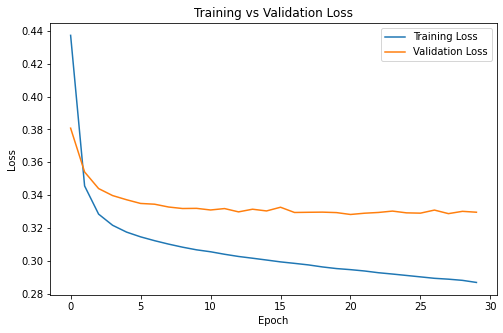

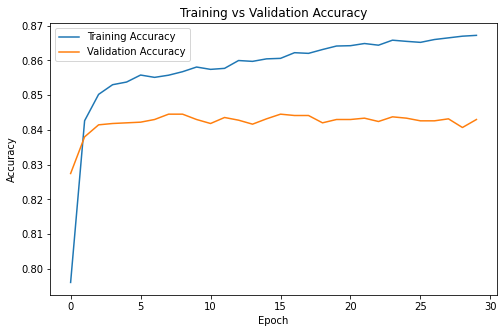

In [32]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [33]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_pred_probs_nn = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_probs_nn >= 0.5).astype(int)

In [34]:
# Compute accuracy and F1 score for the neural network and print the results

acc_nn = accuracy_score(y_test_bin, y_pred_nn)
f1_nn = f1_score(y_test_bin, y_pred_nn, average='binary')

print("Neural Network")
print("Accuracy:", acc_nn)
print("F1 Score:", f1_nn)

Neural Network
Accuracy: 0.8530631045601106
F1 Score: 0.6827974809413324


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. Two hidden layers (64, 32 units) with ReLU activation, narrowing to let the network learn broad patterns then finer combinations. Sigmoid output for binary classification. SGD with learning rate 0.01 (standard balance of speed/stability). Trained 30 epochs (57s). : Clear overfitting after epoch 5-10. Training loss kept dropping (to aroound 0.287) while validation loss plateaued around 0.33. Training accuracy climbed to 86.7% while validation accuracy flattened around 84.3%. Fewer epochs (around 10) likely would've achieved similar validation performance. Accuracy 85.3%, F1 0.6828. Not really surprising given the validation plateau at around 84%, the model generalized about as well as the curves predicted, despite the training/validation gap in loss.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [37]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression': [acc_final, f1_final],
    'Neural Network': [acc_nn, f1_nn]
})
print(results.to_string(index=False))
#
# YOUR CODE HERE

   Metric  Logistic Regression  Neural Network
 Accuracy             0.854445        0.853063
 F1 Score             0.669916        0.682797


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Accuracy stayed nearly the same (85.44% vs 85.31%). F1 score improved slightly with the neural network (0.6699 → 0.6828), meaning it handled the minority >50K class a bit better. No metric got meaningfully worse.
2. Marginally, at best. The F1 gain ( about 0.013) is small relative to the extra cost: more hyperparameters to tune (layers, units, learning rate, epochs), longer training time, and a loss of interpretability compared to Logistic Regression's coefficients. For this problem, the complexity isn't clearly justified.
3. I'd recommend Logistic Regression. It performs almost identically, trains faster, and produces interpretable coefficients that let the client see exactly which factors drive predictions which is very important for a business use case (loans, hiring, assistance programs) where explaining decisions matters and errors need to be auditable for fairness.
4. I'd address class imbalance directly with class weighting or resampling (e.g., SMOTE) to improve minority-class F1 further. I'd also try adding engineered features (e.g., age brackets, capital-gain/loss combined) and test L1 regularization on Logistic Regression for built-in feature selection.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used Claude throughout Part 5 and Part 6 (the traditional ML model and neural network sections) mainly for debugging syntax and runtime errors (a typo in a variable name, a NaN error from unhandled missing values, and a NameError from a mismatched callback class name), for writing boilerplate code for the training/evaluation/grid search cells based on the assignment's structure, and for help drafting language for the written reflection sections after I described my actual results and reasoning to it.
2. The most challenging part was tracking down the NaN error when fitting the Logistic Regression model. My data had missing values in several columns that I'd identified during EDA but never actually imputed before scaling and splitting the data, and the notebook had two separate cells that recreated X from df, so fixing one and not the other meant the fix silently didn't take effect. Debugging this required checking X_train directly for NaN counts to isolate where the problem was, rather than just guessing. A prompt that worked well was asking Claude to add a diagnostic line (np.isnan(X_train).sum()) so I could see hard evidence of where the issue was, instead of continuing to guess.
3. I checked that the code actually ran and produced numeric output matching what I expected (correct data shapes, plausible accuracy/F1 values, sensible-looking coefficients like marital status and capital gains being strong positive predictors of income, which matches domain intuition). I also cross-checked the training/validation curves against the model's test performance to make sure the story was internally consistent, and it ended up matching the overfitting pattern I saw in the loss curves matched the model's actual test F1 falling in the range I'd expect from a plateaued validation curve.
4. I'd handle missing values earlier and more carefully, before writing any downstream code, instead of discovering the gap only after hitting a runtime error. I'd also consolidate the data prep steps into a single reusable cell rather than having duplicate versions of the same logic scattered across the notebook, which is what caused the debugging confusion in the first place. I'd also prep for this earlier, was a lot bigger than I expected. 